# Практична робота 4.8. Аналіз даних з використанням методів глибокого навчання
## Регресія та класифікація за допомогою нейронних мереж (TensorFlow / Keras)

**Варіант: номер за журналом N = 7**

| Параметр | Формула з умови | Значення |
|---|---|---|
| Обсяг даних (регресія) | 1000 × N | **7000** |
| Обсяг даних (класифікація) | 1000 × N | **7000** |
| Кількість класів | N + 2 | **9** |

**Мета:** освоїти генерацію даних для задач регресії та класифікації, побудувати нейронні мережі засобами TensorFlow/Keras, навчити їх і оцінити якість.

**План роботи:**
1. Генерація та візуалізація даних (`make_regression`, `make_classification`).
2. Регресія: нейронна мережа, метрика MSE (додатково RMSE, R²) та порівняння з лінійною регресією.
3. Класифікація: нейронна мережа з softmax-виходом на 9 класів, accuracy, матриця плутанини та порівняння з логістичною регресією.
4. Висновки.

## 1. Параметри варіанта та імпорт бібліотек

In [1]:
# %pip install tensorflow scikit-learn matplotlib seaborn pandas   # за потреби

N = 7                       # номер за журналом
N_SAMPLES = 1000 * N        # 7000
N_CLASSES = N + 2           # 9
RANDOM_STATE = 42

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_STATE)   # фіксує seed для numpy, python і TF
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80
%config InlineBackend.figure_formats = ["jpeg"]
print("TensorFlow:", tf.__version__)
print(f"N = {N}: n_samples = {N_SAMPLES}, n_classes = {N_CLASSES}")

I0000 00:00:1790327730.493877    9226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790327732.097039    9226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
N = 7: n_samples = 7000, n_classes = 9


## 2. Генерація даних
### 2.1. Дані для регресії
Генеруємо 7000 спостережень з 8 ознаками, з яких 6 інформативні, та додаємо шум (`noise=20`). Щоб задача була нелінійною і нейронна мережа мала перевагу над лінійною моделлю, додаємо до цільової змінної нелінійну складову від двох ознак.

In [2]:
X_reg, y_lin = make_regression(n_samples=N_SAMPLES, n_features=8, n_informative=6,
                               noise=20, random_state=RANDOM_STATE)
# нелінійна складова: квадрат і синус від перших двох ознак
y_reg = y_lin + 40 * X_reg[:, 0] ** 2 + 60 * np.sin(2 * X_reg[:, 1])

df_reg = pd.DataFrame(X_reg, columns=[f"x{i}" for i in range(X_reg.shape[1])])
df_reg["y"] = y_reg
print("Розмір:", df_reg.shape)
df_reg.describe().round(2)

Розмір: (7000, 9)


,x0,x1,x2,x3,x4,x5,x6,x7,y
count,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00
mean,0.01,-0.00,-0.01,-0.02,0.00,0.01,-0.00,0.01,42.02
std,1.01,0.99,1.01,1.00,1.00,1.00,1.00,0.99,190.63
min,-3.42,-4.47,-4.30,-3.37,-3.69,-3.66,-3.27,-3.84,-554.46
25%,-0.66,-0.68,-0.70,-0.69,-0.68,-0.66,-0.69,-0.66,-91.28
50%,0.01,0.01,-0.01,-0.02,0.01,-0.00,0.00,0.02,39.33
75%,0.68,0.68,0.67,0.65,0.69,0.70,0.66,0.68,167.86
max,3.61,3.75,3.38,3.85,4.48,3.60,3.93,3.73,960.28


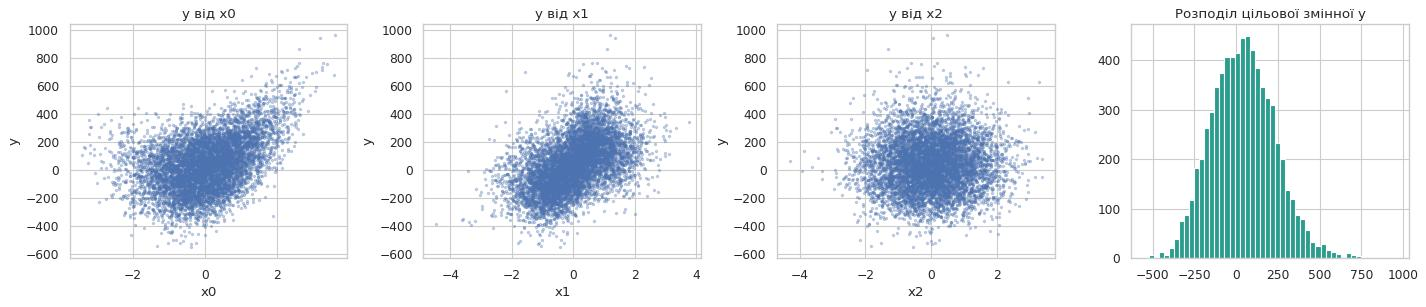

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes[:3], ["x0", "x1", "x2"]):
    ax.scatter(df_reg[col], df_reg["y"], s=4, alpha=0.3)
    ax.set_xlabel(col); ax.set_ylabel("y"); ax.set_title(f"y від {col}")
axes[3].hist(df_reg["y"], bins=50, color="#2a9d8f")
axes[3].set_title("Розподіл цільової змінної y")
plt.tight_layout(); plt.show()

На графіках видно параболічну залежність від `x0` та хвилеподібну від `x1`: лінійна модель такі залежності не опише.

### 2.2. Дані для класифікації
7000 спостережень, **9 класів**, 20 ознак (12 інформативних, 4 надлишкові, 4 шумові). Параметр `class_sep=1.0` робить класи частково перекритими, щоб задача не була тривіальною.

In [4]:
X_clf, y_clf = make_classification(n_samples=N_SAMPLES, n_features=20, n_informative=12,
                                   n_redundant=4, n_classes=N_CLASSES, n_clusters_per_class=2,
                                   class_sep=1.0, flip_y=0.01, random_state=RANDOM_STATE)
print("Розмір X:", X_clf.shape)
print("Кількість об'єктів у класах:", np.bincount(y_clf))

Розмір X: (7000, 20)
Кількість об'єктів у класах: [781 775 780 778 778 777 774 780 777]


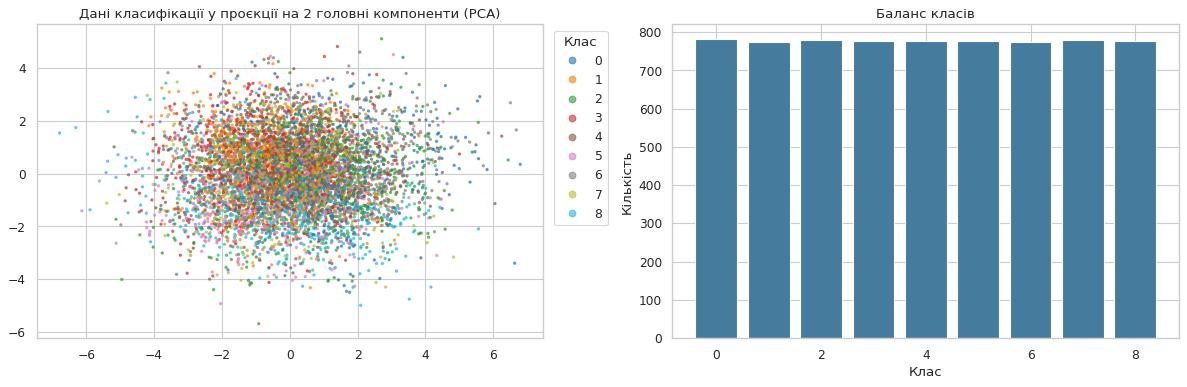

In [5]:
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(StandardScaler().fit_transform(X_clf))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_clf, cmap="tab10", s=4, alpha=0.6)
axes[0].legend(*sc.legend_elements(), title="Клас", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].set_title("Дані класифікації у проєкції на 2 головні компоненти (PCA)")
axes[1].bar(range(N_CLASSES), np.bincount(y_clf), color="#457b9d")
axes[1].set_xlabel("Клас"); axes[1].set_ylabel("Кількість"); axes[1].set_title("Баланс класів")
plt.tight_layout(); plt.show()

Класи збалансовані (~778 об'єктів у кожному). У двовимірній проєкції вони сильно перекриваються, тому для розділення потрібні всі 20 ознак і нелінійна модель.

## 3. Регресія
### 3.1. Розподіл і масштабування
Дані ділимо на train (64 %), validation (16 %) і test (20 %). Validation використовуємо для ранньої зупинки, test лише для фінальної оцінки. Нейронні мережі чутливі до масштабу, тому стандартизуємо і ознаки, і цільову змінну (параметри scaler обчислюються тільки на train).

In [6]:
Xr_tmp, Xr_test, yr_tmp, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
Xr_train, Xr_val, yr_train, yr_val = train_test_split(Xr_tmp, yr_tmp, test_size=0.2, random_state=RANDOM_STATE)

sx, sy = StandardScaler().fit(Xr_train), StandardScaler().fit(yr_train.reshape(-1, 1))
Xr_train_s, Xr_val_s, Xr_test_s = sx.transform(Xr_train), sx.transform(Xr_val), sx.transform(Xr_test)
yr_train_s = sy.transform(yr_train.reshape(-1, 1)).ravel()
yr_val_s = sy.transform(yr_val.reshape(-1, 1)).ravel()
print("train / val / test:", len(Xr_train), len(Xr_val), len(Xr_test))

train / val / test: 4480 1120 1400


### 3.2. Архітектура нейронної мережі
Багатошаровий перцептрон: `8 → Dense(64, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1)`. Лінійний вихід, функція втрат MSE, оптимізатор Adam. `EarlyStopping` зупиняє навчання, коли `val_loss` перестає зменшуватися, і відновлює найкращі ваги.

In [7]:
model_reg = keras.Sequential([
    keras.Input(shape=(Xr_train_s.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
], name="regression_mlp")
model_reg.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model_reg.summary()

Model: "regression_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
hist_reg = model_reg.fit(Xr_train_s, yr_train_s, validation_data=(Xr_val_s, yr_val_s),
                         epochs=300, batch_size=64, callbacks=[early], verbose=0)
print("Навчання зупинено на епосі:", len(hist_reg.history["loss"]))

Навчання зупинено на епосі: 55


### 3.3. Оцінка: MSE, RMSE, R² і порівняння з лінійною регресією

In [9]:
yr_pred = sy.inverse_transform(model_reg.predict(Xr_test_s, verbose=0)).ravel()
lin = LinearRegression().fit(Xr_train_s, yr_train)
yr_pred_lin = lin.predict(Xr_test_s)

def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse), "R²": r2_score(y_true, y_pred)}

reg_results = pd.DataFrame({"Лінійна регресія (baseline)": reg_metrics(yr_test, yr_pred_lin),
                            "Нейронна мережа (Keras)": reg_metrics(yr_test, yr_pred)}).T.round(3)
reg_results

,MSE,RMSE,R²
Лінійна регресія (baseline),5299.815,72.800,0.863
Нейронна мережа (Keras),807.068,28.409,0.979


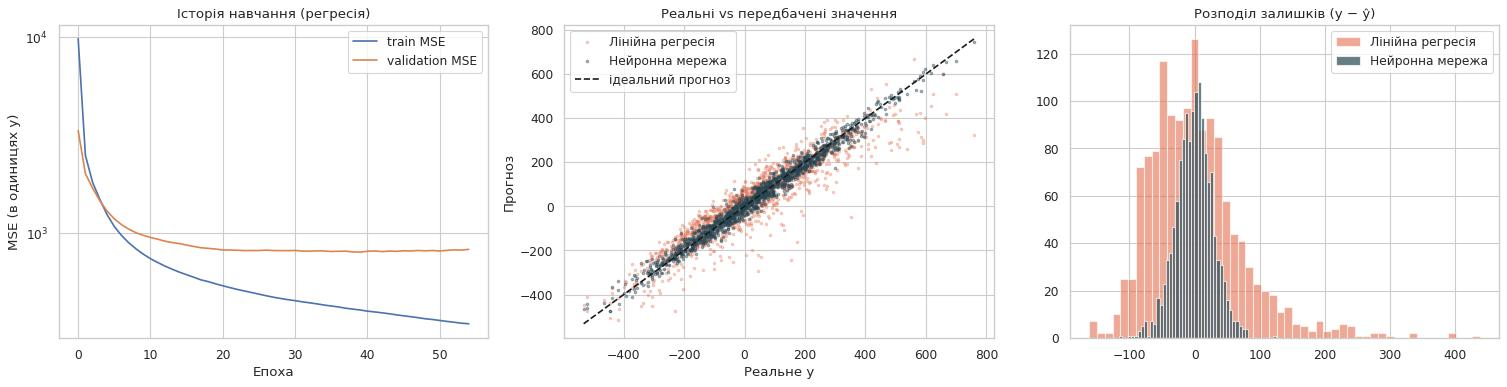

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].plot(np.array(hist_reg.history["loss"]) * sy.scale_[0] ** 2, label="train MSE")
axes[0].plot(np.array(hist_reg.history["val_loss"]) * sy.scale_[0] ** 2, label="validation MSE")
axes[0].set_yscale("log"); axes[0].set_xlabel("Епоха"); axes[0].set_ylabel("MSE (в одиницях y)")
axes[0].set_title("Історія навчання (регресія)"); axes[0].legend()

lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
axes[1].scatter(yr_test, yr_pred_lin, s=5, alpha=0.3, label="Лінійна регресія", color="#e76f51")
axes[1].scatter(yr_test, yr_pred, s=5, alpha=0.4, label="Нейронна мережа", color="#264653")
axes[1].plot(lims, lims, "k--", label="ідеальний прогноз")
axes[1].set_xlabel("Реальне y"); axes[1].set_ylabel("Прогноз"); axes[1].set_title("Реальні vs передбачені значення"); axes[1].legend()

axes[2].hist(yr_test - yr_pred_lin, bins=50, alpha=0.6, label="Лінійна регресія", color="#e76f51")
axes[2].hist(yr_test - yr_pred, bins=50, alpha=0.7, label="Нейронна мережа", color="#264653")
axes[2].set_title("Розподіл залишків (y − ŷ)"); axes[2].legend()
plt.tight_layout(); plt.show()

## 4. Класифікація
### 4.1. Розподіл і масштабування
Той самий протокол 64/16/20 зі стратифікацією за класом, щоб у кожній частині була однакова частка всіх 9 класів.

In [11]:
Xc_tmp, Xc_test, yc_tmp, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE)
Xc_train, Xc_val, yc_train, yc_val = train_test_split(Xc_tmp, yc_tmp, test_size=0.2, stratify=yc_tmp, random_state=RANDOM_STATE)
sc = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_val_s, Xc_test_s = sc.transform(Xc_train), sc.transform(Xc_val), sc.transform(Xc_test)
print("train / val / test:", len(Xc_train), len(Xc_val), len(Xc_test))

train / val / test: 4480 1120 1400


### 4.2. Архітектура нейронної мережі
`20 → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.3) → Dense(9, Softmax)`.
Вихідний шар має 9 нейронів (за кількістю класів) із softmax, тобто повертає ймовірності класів. Функція втрат `sparse_categorical_crossentropy` дозволяє подавати мітки цілими числами без one-hot кодування. Dropout зменшує перенавчання.

In [12]:
model_clf = keras.Sequential([
    keras.Input(shape=(Xc_train_s.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(N_CLASSES, activation="softmax"),
], name="classification_mlp")
model_clf.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_clf.summary()

Model: "classification_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,529 (45.04 KB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_c = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
hist_clf = model_clf.fit(Xc_train_s, yc_train, validation_data=(Xc_val_s, yc_val),
                         epochs=300, batch_size=64, callbacks=[early_c], verbose=0)
print("Навчання зупинено на епосі:", len(hist_clf.history["loss"]))

Навчання зупинено на епосі: 216


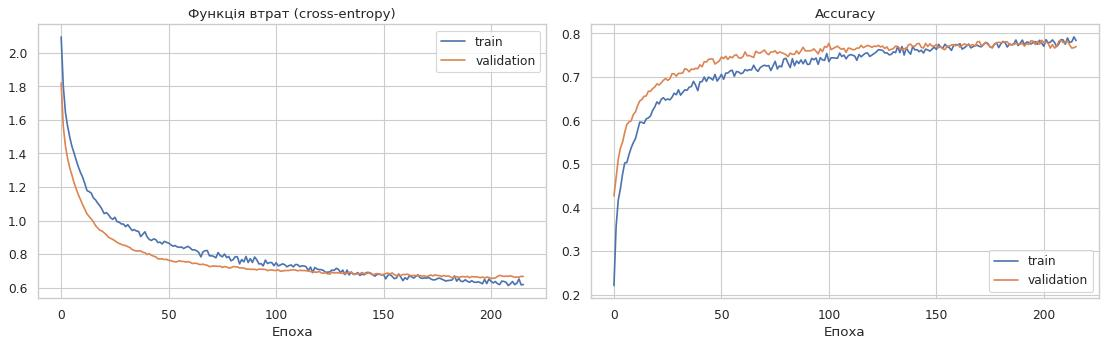

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(hist_clf.history["loss"], label="train"); axes[0].plot(hist_clf.history["val_loss"], label="validation")
axes[0].set_title("Функція втрат (cross-entropy)"); axes[0].set_xlabel("Епоха"); axes[0].legend()
axes[1].plot(hist_clf.history["accuracy"], label="train"); axes[1].plot(hist_clf.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Епоха"); axes[1].legend()
plt.tight_layout(); plt.show()

### 4.3. Оцінка: accuracy, матриця плутанини, порівняння з логістичною регресією

In [15]:
yc_pred = model_clf.predict(Xc_test_s, verbose=0).argmax(axis=1)
logreg = LogisticRegression(max_iter=2000).fit(Xc_train_s, yc_train)
yc_pred_lr = logreg.predict(Xc_test_s)

acc_nn, acc_lr = accuracy_score(yc_test, yc_pred), accuracy_score(yc_test, yc_pred_lr)
clf_results = pd.DataFrame({"Accuracy": [acc_lr, acc_nn]},
                           index=["Логістична регресія (baseline)", "Нейронна мережа (Keras)"]).round(3)
print(f"Випадкове вгадування для 9 класів: {1/N_CLASSES:.3f}")
clf_results

Випадкове вгадування для 9 класів: 0.111


,Accuracy
Логістична регресія (baseline),0.436
Нейронна мережа (Keras),0.786


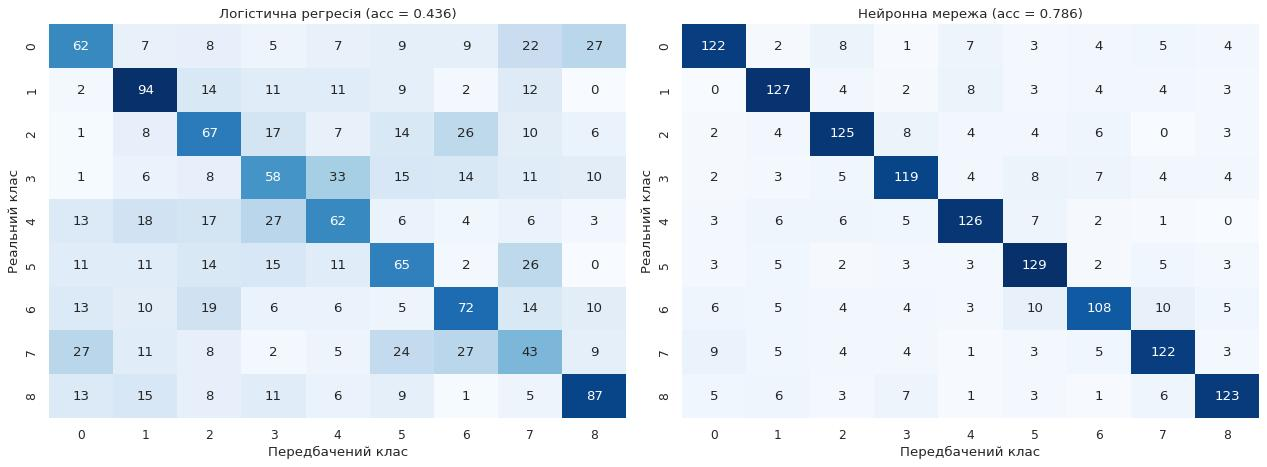

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, pred, title in [(axes[0], yc_pred_lr, f"Логістична регресія (acc = {acc_lr:.3f})"),
                        (axes[1], yc_pred, f"Нейронна мережа (acc = {acc_nn:.3f})")]:
    cm = confusion_matrix(yc_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Передбачений клас"); ax.set_ylabel("Реальний клас"); ax.set_title(title)
plt.tight_layout(); plt.show()

In [17]:
print(classification_report(yc_test, yc_pred, digits=3))

              precision    recall  f1-score   support

           0      0.803     0.782     0.792       156
           1      0.779     0.819     0.799       155
           2      0.776     0.801     0.789       156
           3      0.778     0.763     0.770       156
           4      0.803     0.808     0.805       156
           5      0.759     0.832     0.794       155
           6      0.777     0.697     0.735       155
           7      0.777     0.782     0.780       156
           8      0.831     0.794     0.812       155

    accuracy                          0.786      1400
   macro avg      0.787     0.786     0.786      1400
weighted avg      0.787     0.786     0.786      1400



In [18]:
# Які пари класів модель плутає найчастіше
cm = confusion_matrix(yc_test, yc_pred)
np.fill_diagonal(cm, 0)
pairs = sorted(((cm[i, j], i, j) for i in range(N_CLASSES) for j in range(N_CLASSES) if cm[i, j] > 0), reverse=True)[:5]
pd.DataFrame(pairs, columns=["Помилок", "Реальний клас", "Передбачений клас"])

,Помилок,Реальний клас,Передбачений клас
0,10,6,7
1,10,6,5
2,9,7,0
3,8,3,5
4,8,2,3


## 5. Висновки

**Дані** згенеровано відповідно до варіанта N = 7: по 7000 спостережень для обох задач, 9 класів у задачі класифікації. Класи збалансовані, тож accuracy є коректною метрикою.

**Регресія.** Нейронна мережа з трьома прихованими шарами досягла на тестовому наборі **MSE ≈ 807** (RMSE ≈ 28.4, R² ≈ 0.979). Лінійна регресія на тих самих даних має MSE ≈ 5300 (R² ≈ 0.863). MSE мережі приблизно в 6.5 раза менша, бо мережа відтворює нелінійні складові (параболу за `x0` та синусоїду за `x1`), які лінійна модель пропускає. Точки прогнозу мережі щільно лежать уздовж діагоналі, залишки симетричні й зосереджені біля нуля. Залишкова похибка близька до рівня закладеного шуму, тож з цих даних більше отримати складно.

**Класифікація.** Мережа з softmax-виходом на 9 класів досягла на тесті **accuracy ≈ 0.79**. Для порівняння: випадкове вгадування дає 0.11, а логістична регресія 0.44. Кожен клас має в генераторі два кластери (`n_clusters_per_class=2`), тому межі між класами нелінійні, і саме тут нейронна мережа має перевагу. Матриця плутанини має виражену діагональ. Precision і recall по класах рівномірні (0.70–0.83), тобто модель не «жертвує» жодним класом. Найчастіше плутаються класи 6 ↔ 5/7, і найслабший recall має клас 6 (≈ 0.70).

**Навчання.** EarlyStopping за `val_loss` зупинив регресійну модель на 55-й епосі, а класифікаційну на 216-й, з відновленням найкращих ваг. У класифікації криві train і validation ідуть майже разом, отже перенавчання немає, чому сприяє Dropout(0.3). У регресії train-MSE продовжує падати (до ≈ 350), а validation-MSE стабілізується на ≈ 800 уже після 20-ї епохи. Цей розрив свідчить про початок перенавчання: мережа починає запам'ятовувати шум. Рання зупинка обмежила його, а подальше зменшення можливе через Dropout або L2-регуляризацію.

**Загальний висновок.** На обох задачах нейронні мережі суттєво перевершили лінійні baseline-моделі, бо дані містять нелінійні залежності. Порівняння з baseline обов'язкове: воно показує, що складність мережі виправдана. Можливі покращення: підбір архітектури та learning rate (наприклад, KerasTuner), batch normalization, а для класифікації ще й аналіз ознак, які розділяють класи 5–7.